<center>
Открытый курс по машинному обучению. Сессия № 3
Автор материала: программист-исследователь Mail.ru Group, старший преподаватель Факультета Компьютерных Наук ВШЭ Юрий Кашницкий. Материал распространяется на условиях лицензии [Creative Commons CC BY-NC-SA 4.0](https://creativecommons.org/licenses/by-nc-sa/4.0/). Можно использовать в любых целях (редактировать, поправлять и брать за основу), кроме коммерческих, но с обязательным упоминанием автора материала.

# <center> Домашнее задание № 1
## <center> Анализ данных по сердечно-сосудистым заболеваниям
*Идеальный просмотр Jupyter notebooks возможен только локально, GitHub и nbviewer могут неправильно отбражать формулы или картинки.*

**В задании предлагается с помощью Pandas ответить на несколько вопросов по данным о сердечно-сосудистых заболеваниях (качать данные не надо, они уже есть в репозитории). Данные использовались в соревновании [Ml Boot Camp 5](http://mlbootcamp.ru/round/12/sandbox/).**

**Заполните код в клетках (где написано "Ваш код здесь") и ответьте на вопросы.**

В соревновании предлагалось определить наличие/отсутствие сердечно-сосудистых заболеваний (ССЗ) по результатам осмотра пациента.

**Описание данных.**

Датасет сформирован из реальных клинических анализов, и в нём используются признаки, которые можно разбить на 3 группы:

Объективные признаки:

 - Возраст (age)
 - Рост (height)
 - Вес (weight)
 - Пол (gender)

---


Результаты измерения:

 - Артериальное давление верхнее и нижнее (ap_hi, ap_lo)
 - Холестерин (cholesterol)
 - Глюкоза (gluc)



---


Субъективные признаки (со слов пациентов):

 - Курение (smoke)
 - Употребление алкоголя (alco)
 - Физическая активность (active)


---


Целевой признак (который интересно будет прогнозировать):
 - Наличие сердечно-сосудистых заболеваний по результатам классического врачебного осмотра (cardio)


---


Значения показателей холестерина и глюкозы представлены одним из трех классов: норма, выше нормы, значительно выше нормы. Значения субъективных признаков — бинарны.

Все показатели даны на момент осмотра.

Считываем данные из CSV-файла в объект pandas DataFrame.  

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("https://stepik.org/media/attachments/course/57984/train.csv",
                 sep=';',
                 index_col='id')

In [3]:
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
id,,,,,,,,,,,,
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0


**<font color='red'>Вопрос 1.</font> Сколько мужчин и женщин представлено в этом наборе данных? Не было дано расшифровки признака "пол" (какому полу соответствует 1, а какому – 2 в признаке ``gender``) – это определите, посмотрев также на рост при разумном предположении, что в среднем мужчины выше (здесь и далее под средним понимается среднее арифметическое).**

**<font color='red'>Варианты:</font>**
- 45470 женщин и 24530 мужчин
- 45470 мужчин и 24530 женщин
- 45530 женщин и 24470 мужчин
- 45530 мужчин и 24470 женщин

gender
1    161.355612
2    169.947895
Name: height, dtype: float64
gender
1    45530
2    24470
Name: count, dtype: int64


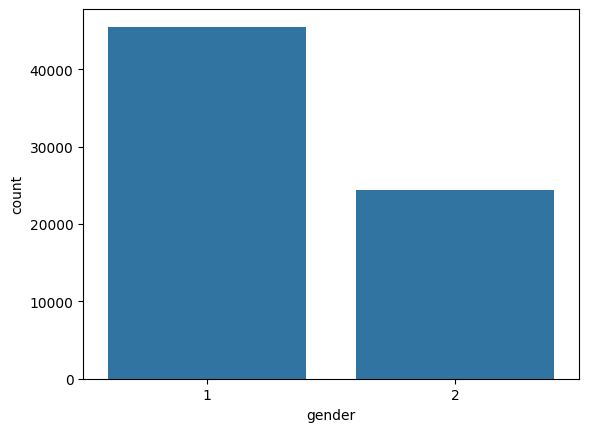

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

avg_height_by_gender = df.groupby('gender')['height'].mean()
print(avg_height_by_gender)
gender_counts = df['gender'].value_counts()
print(gender_counts)
sns.countplot(x='gender', data=df)
plt.show()

**<font color='red'>Вопрос 2.</font> Кто в среднем реже указывает, что употребляет алкоголь – мужчины или женщины?**

**<font color='red'>Варианты:</font>**
- мужчины
- женщины

In [5]:
avg_height_by_gender = df.groupby('gender')['alco'].mean()
print(avg_height_by_gender)


gender
1    0.025500
2    0.106375
Name: alco, dtype: float64


**<font color='red'>Вопрос 3.</font> Во сколько раз (округленно, `round`) процент курящих среди мужчин больше, чем процент курящих среди женщин (по крайней мере, по этим анкетным данным)?**

**<font color='red'>Варианты:</font>**
- 4
- 8
- 12
- 16

In [6]:
count_female_smoke = df[df['gender'] == 1]['smoke'].mean() * 100
count_male_smoke = df[df['gender'] == 2]['smoke'].mean() * 100

print(count_female_smoke, count_male_smoke)
x = count_male_smoke / count_female_smoke
print(x)

1.7856358444981333 21.88802615447487
12.257833097333833


**<font color='red'>Вопрос 4.</font> Вы наверняка заметили, что значения возраста какие-то странные. Догадайтесь, в чём здесь измеряется возраст, и ответьте, на сколько месяцев (примерно) отличаются средние значения возраста курящих и некурящих.**

**<font color='red'>Варианты:</font>**
- 10
- 15
- 20
- 25

In [7]:
df['new_age'] = df['age'] / 365
people_smoke = df[df['smoke'] == 1]['new_age'].mean() * 12
people_not_smoke = df[df['smoke'] == 0]['new_age'].mean() * 12
diff_people = abs(people_smoke - people_not_smoke)
print(f'Курящие {people_smoke}, Некурящие {people_not_smoke}')
print(diff_people)

Курящие 627.6439537501915, Некурящие 641.2734486592699
13.629494909078403


In [8]:
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,new_age
id,,,,,,,,,,,,,
0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50.391781
1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55.419178
2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51.663014
3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48.282192
4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47.873973


**<font color='red'>Вопрос 5.</font> В [статье](https://ru.wikipedia.org/wiki/Сердечно-сосудистый_риск) на Википедии про сердечно-сосудистый риск показана шкала SCORE для расчёта риска смерти от сердечно-сосудистого заболевания в ближайшие 10 лет. Вот она:**
<img src='https://habrastorage.org/webt/gg/38/vf/gg38vfl5ql8obqjmlsvt9es76p8.png' width=70%>

Давайте посмотрим на правый верхний прямоугольник, отображающий сегмент курящих мужчин в возрасте от 60 до 64 лет включительно. (Неочевидно, но тут для возраста и давления цифры означают верхнюю границу, и она не включается).

Видим 9-ку в левом нижнем углу этого прямоугольника и 47 – в правом верхнем. То есть если при этом систолическое (т.е. верхнее) артериальное давление – меньше 120 мм рт.ст., а уровень холестерина – 4 ммоль/л, то риск ССЗ оценивается примерно в 5 раз ниже, чем если бы давление лежало в интервале [160, 180), а холестерина было бы 8 ммоль/л.

Давайте посчитаем аналогичное значение, но на наших данных.


---


Уточнения:
- Создайте новый признак ``age_years`` – возраст в годах, округлив до целых (`round`). Для данного примера отберите курящих мужчин от 60 до 64 лет включительно
- Категории уровня холестрина на рисунке и в наших данных отличаются. Отображение значений на картинке в значения признака ``cholesterol`` следующее: 4 ммоль/л $\rightarrow$ 1, 5-7 ммоль/л $\rightarrow$ 2, 8 ммоль/л $\rightarrow$ 3.
- Интересуют 2 подвыборки курящих мужчин возраста от 60 до 64 лет включительно: первая с верхним артериальным давлением строго меньше 120 мм рт.ст. и концентрацией холестерина – 4 ммоль/л, а вторая – с верхним артериальным давлением от 160 (включительно) до 180 мм рт.ст. (не включительно) и концентрацией холестерина – 8 ммоль/л.

Во сколько раз (округленно, `round`) отличаются доли больных людей (согласно целевому признаку, `cardio`) в этих двух подвыборках? Посчитайте на наших данных.

**<font color='red'>Варианты:</font>**
- 2
- 3
- 4
- 5

In [19]:
#Выборка курящих мужчин в возрасте от 60 до 64 вкл
mens = df[(df['gender'] == 1) & (df['smoke'] == 1) & round((df['new_age'] >= 60) & (df['new_age'] <= 64))]
# print(mens)

#Выборка базовой таблицы, но с меньшим арт давлением (< 120 и холестерин = 1)
art1_hol1 = mens[(mens['ap_hi'] < 120) & (mens['cholesterol'] == 1)]
# print(art1_hol1)
#Выборка базовой таблицы, но с большим арт давлением и холестерином = 3
art2_hol2 = mens[(mens['ap_hi'] >= 160) & (mens['ap_hi'] < 180) & (mens['cholesterol'] == 3)]
# print(art2_hol2)

#Считаем доли
count_art1_hol1 = art1_hol1['cardio'].mean()
count_art2_hol2 = art2_hol2['cardio'].mean()
print(f'Доля людей, у которых арт давление <120: {count_art1_hol1} , доля людей, у которых >=160 и <180: {count_art2_hol2}')
print(f'Отношение одних людей от других составляет {round(count_art2_hol2/count_art1_hol1)}')


Доля людей, у которых арт давление <120: 0.4 , доля людей, у которых >=160 и <180: 1.0
Отношение одних людей от других составляет 2


**<font color='red'>Вопрос 6.</font> Постройте новый признак – BMI ([Body Mass Index](https://en.wikipedia.org/wiki/Body_mass_index)). Для этого надо вес в килограммах поделить на квадрат роста в метрах. Нормальными считаются значения BMI от 18.5 до 25. Выберите верные утверждения.**

**<font color='red'>Утверждения:</font>**
- Медианный BMI по выборке превышает норму
- У женщин в среднем BMI ниже, чем у мужчин
- У здоровых в среднем BMI выше, чем у больных
- В сегменте здоровых и непьющих мужчин в среднем BMI ближе к норме, чем в сегменте здоровых и непьющих женщин

In [35]:
# Quetelet_index = df['weight'] / ((df['height']/100) **2)
# print(Quetelet_index)
df['bmi'] =  df['weight'] / ((df['height']/100) **2)
# df.head()

# Утверждение 1 - правда
quetelet_meadian = df['bmi'].median()
print(f'Медиана BMI {quetelet_meadian}\n')

# Утверждение 2 - ложь
BMI_female = df[df['gender'] == 1]['bmi'].mean()
BMI_male = df[df['gender'] == 2]['bmi'].mean()
print(f'BMI у женщин {BMI_female}, BMI у мужчин {BMI_male}\n')

# Утверждение 3 - правда
BMI_heath = df[df['cardio'] == 0]['bmi'].mean()
BMI_sick = df[df['cardio'] == 1]['bmi'].mean()
print(f'BMI у больных {BMI_sick}, BMI у здоровых {BMI_heath}\n')

# Утверждение 4 - правда
BMI_heath_male = df[(df['gender'] == 2) & (df['cardio'] == 0) & (df['alco'] == 0)]['bmi'].mean()
BMI_sick_female = df[(df['gender'] == 1) & (df['cardio'] == 1) & (df['alco'] == 1)]['bmi'].mean()
print(f'BMI у здоровых непьющих мужчин {BMI_heath_male}, BMI у больных пьющих женщин {BMI_sick_female}\n')


Медиана BMI 26.374068120774975

BMI у женщин 27.98758344183285, BMI у мужчин 26.754442357289356

BMI у больных 28.56606062701535, BMI у здоровых 26.5481752067945

BMI у здоровых непьющих мужчин 25.87263807546017, BMI у больных пьющих женщин 30.81234721276659



**<font color='red'>Вопрос 7.</font> Cколько процентов (округленно, round) людей, отметивших, что они и курят, и пьют, занимаются физической активностью?**

**<font color='red'>Утверждения:</font>**
- 85
- 87
- 3
- 15

In [57]:
алкаши_и_курящие = df[(df['smoke'] == 1) & (df['alco'] == 1)]
процентное_соотношение = round(алкаши_и_курящие['active'].mean() * 100)
print(f'{процентное_соотношение}%')

85%


**<font color='red'>График.</font> Изобразите на одном графике распределение по возрасту (в годах) в виде bar chart и количество людей с сердечно-сосудистыми заболеваниями в этих возрастных категориях**

---



/tmp/ipykernel_16027/3302870061.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats = df.groupby('age_group').agg(


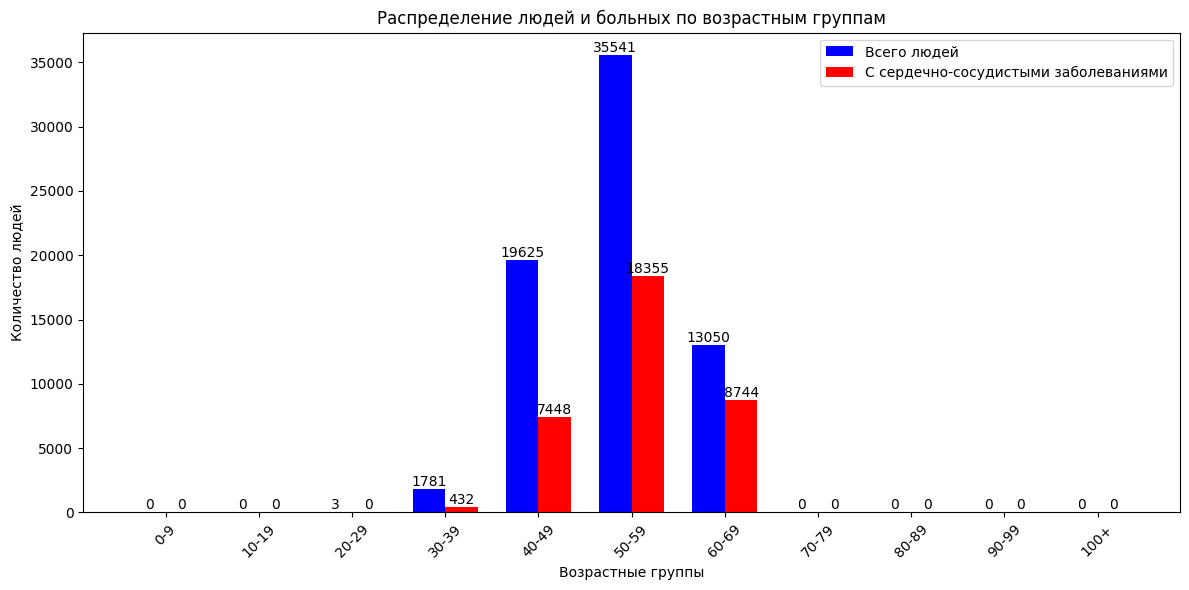

In [55]:
#Отдельные возрастные категории
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 120]
labels = ['0-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '90-99', '100+']
df['age_group'] = pd.cut(df['new_age'], bins=bins, labels=labels, right=False)

age_stats = df.groupby('age_group').agg(
    total=('age_group', 'count'),
    cardio_count=('cardio', lambda x: (x == 1).sum())
)

x = np.arange(len(age_stats
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars_total = ax.bar(x - width/2, age_stats['total'], width, label='Всего людей', color='blue')
bars_cardio = ax.bar(x + width/2, age_stats['cardio_count'], width, label='С сердечно-сосудистыми заболеваниями', color='red')

# Настройки
ax.set_xlabel('Возрастные группы')
ax.set_ylabel('Количество людей')
ax.set_title('Распределение людей и больных по возрастным группам')
ax.set_xticks(x)
ax.set_xticklabels(age_stats.index, rotation=45)
ax.legend()

# Добавим значения над столбцами
for bar in bars_total:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom')

for bar in bars_cardio:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom')

plt.tight_layout()
plt.show()
